# Laboratorio 4 — Fundamentos de Aprendizaje por Refuerzo y Gymnasium

## 3. Módulo de prueba: primeros pasos con Gymnasium

Se practica la API de Gymnasium con agentes simples (aleatorio y una política diseñada a mano); no se entrena ningún agente inteligente en esta sección.

### 3.1 Instalación y verificación de la versión

In [1]:
import sys
!{sys.executable} -m pip install -q gymnasium matplotlib numpy

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

print("Gymnasium version:", gym.__version__)

Gymnasium version: 1.3.0


### 3.2 Instancia de CartPole-v1: espacios de observación y acción

In [2]:
env = gym.make("CartPole-v1")

print("=== Espacio de observación ===")
print("Objeto:", env.observation_space)
print("Tipo:", type(env.observation_space).__name__)
print("Dimensión (shape):", env.observation_space.shape)
print("Límite inferior (low):", env.observation_space.low)
print("Límite superior (high):", env.observation_space.high)

print("\n=== Espacio de acción ===")
print("Objeto:", env.action_space)
print("Tipo:", type(env.action_space).__name__)
print("Número de acciones (n):", env.action_space.n)

env.close()

=== Espacio de observación ===
Objeto: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Tipo: Box
Dimensión (shape): (4,)
Límite inferior (low): [-4.8               -inf -0.41887903        -inf]
Límite superior (high): [4.8               inf 0.41887903        inf]

=== Espacio de acción ===
Objeto: Discrete(2)
Tipo: Discrete
Número de acciones (n): 2


### 3.3 Agente aleatorio en CartPole-v1 (5 episodios)

Función reutilizable que ejecuta un agente aleatorio (`action_space.sample()`) durante `n_episodios` completos, registrando pasos sobrevividos y retorno total de cada episodio.

In [3]:
def run_random_agent(env_name, n_episodes=5, seed=42, **make_kwargs):
    """Ejecuta un agente aleatorio en env_name durante n_episodes episodios completos."""
    env = gym.make(env_name, **make_kwargs)
    returns, steps_per_episode = [], []

    for ep in range(n_episodes):
        obs, info = env.reset(seed=seed + ep)
        total_reward = 0.0
        n_steps = 0
        terminated = truncated = False

        while not (terminated or truncated):
            action = env.action_space.sample()
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            n_steps += 1

        returns.append(total_reward)
        steps_per_episode.append(n_steps)
        print(f"Episodio {ep + 1}: steps={n_steps}, return={total_reward:.1f}")

    env.close()
    return returns, steps_per_episode


print("--- Agente aleatorio: CartPole-v1 ---")
cartpole_random_returns, cartpole_random_steps = run_random_agent("CartPole-v1", n_episodes=5)

--- Agente aleatorio: CartPole-v1 ---
Episodio 1: steps=37, return=37.0
Episodio 2: steps=18, return=18.0
Episodio 3: steps=14, return=14.0
Episodio 4: steps=16, return=16.0
Episodio 5: steps=13, return=13.0


### 3.4 Gráfica de recompensa por episodio (CartPole-v1)

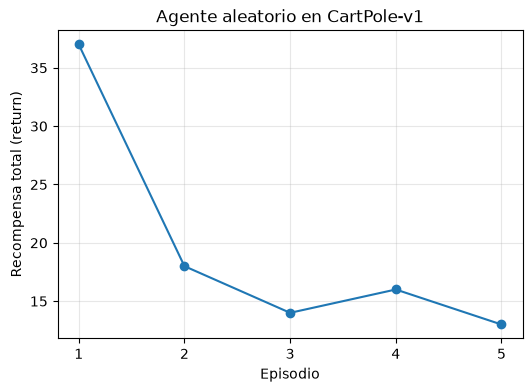

In [4]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(cartpole_random_returns) + 1), cartpole_random_returns, marker="o")
plt.xlabel("Episodio")
plt.ylabel("Recompensa total (return)")
plt.title("Agente aleatorio en CartPole-v1")
plt.xticks(range(1, len(cartpole_random_returns) + 1))
plt.grid(True, alpha=0.3)
plt.show()

### 3.5 Agente aleatorio en un segundo entorno discreto: FrozenLake-v1

Se eligió **FrozenLake-v1** (con `is_slippery=True`, la configuración por defecto) como segundo entorno: es discreto tanto en observación como en acción, y su dinámica estocástica (el agente puede resbalar en direcciones distintas a la elegida) lo hace muy diferente de CartPole-v1.

--- Agente aleatorio: FrozenLake-v1 (is_slippery=True) ---
Episodio 1: steps=6, return=0.0
Episodio 2: steps=9, return=0.0
Episodio 3: steps=8, return=0.0
Episodio 4: steps=2, return=0.0
Episodio 5: steps=4, return=0.0


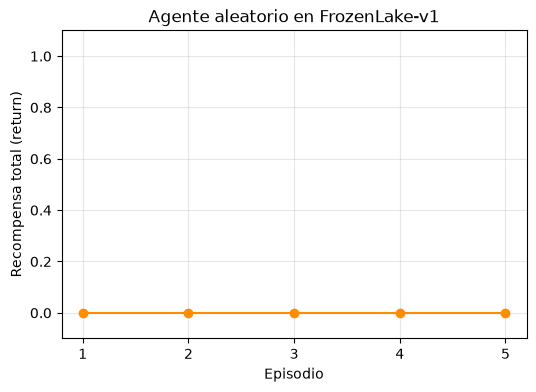


CartPole-v1   -> steps promedio: 19.6, return promedio: 19.6
FrozenLake-v1 -> steps promedio: 5.8, return promedio: 0.00


In [5]:
print("--- Agente aleatorio: FrozenLake-v1 (is_slippery=True) ---")
frozenlake_random_returns, frozenlake_random_steps = run_random_agent(
    "FrozenLake-v1", n_episodes=5, is_slippery=True
)

plt.figure(figsize=(6, 4))
plt.plot(
    range(1, len(frozenlake_random_returns) + 1),
    frozenlake_random_returns,
    marker="o",
    color="darkorange",
)
plt.xlabel("Episodio")
plt.ylabel("Recompensa total (return)")
plt.title("Agente aleatorio en FrozenLake-v1")
plt.xticks(range(1, len(frozenlake_random_returns) + 1))
plt.ylim(-0.1, 1.1)
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nCartPole-v1   -> steps promedio: {np.mean(cartpole_random_steps):.1f}, "
      f"return promedio: {np.mean(cartpole_random_returns):.1f}")
print(f"FrozenLake-v1 -> steps promedio: {np.mean(frozenlake_random_steps):.1f}, "
      f"return promedio: {np.mean(frozenlake_random_returns):.2f}")

**Nota sobre el return = 0.0 en FrozenLake-v1:** con solo 5 episodios es normal no observar ningún éxito, ya que la recompensa es escasa (+1 solo al llegar a la meta, 0 en cualquier otro caso, incluido caer en un agujero) y la dinámica es estocástica (`is_slippery=True` hace que la acción elegida solo se ejecute ~1/3 de las veces). Para confirmar que un agente aleatorio sí puede llegar a la meta ocasionalmente (solo que es poco probable), se repite el experimento con muchos más episodios y se mide la tasa de éxito.

In [6]:
def random_agent_success_rate(env_name, n_episodes=1000, seed=0, **make_kwargs):
    """Corre muchos episodios con un agente aleatorio y mide la fracción que termina con return > 0."""
    env = gym.make(env_name, **make_kwargs)
    successes = 0
    total_return = 0.0

    for ep in range(n_episodes):
        obs, info = env.reset(seed=seed + ep)
        terminated = truncated = False
        ep_return = 0.0
        while not (terminated or truncated):
            action = env.action_space.sample()
            obs, reward, terminated, truncated, info = env.step(action)
            ep_return += reward
        total_return += ep_return
        if ep_return > 0:
            successes += 1

    env.close()
    return successes, n_episodes, total_return / n_episodes


N_TRIALS = 2000
successes, n_episodes, avg_return = random_agent_success_rate(
    "FrozenLake-v1", n_episodes=N_TRIALS, is_slippery=True
)

print(f"Agente aleatorio en FrozenLake-v1 sobre {n_episodes} episodios:")
print(f"  Episodios exitosos (return=1.0): {successes} ({100 * successes / n_episodes:.2f}%)")
print(f"  Return promedio: {avg_return:.4f}")

Agente aleatorio en FrozenLake-v1 sobre 2000 episodios:
  Episodios exitosos (return=1.0): 33 (1.65%)
  Return promedio: 0.0165


### 3.6 Política simple (no aprendida) para CartPole-v1

Regla heurística basada en conocimiento del dominio: si la **velocidad angular del poste** (`obs[3]`) es positiva (el poste cae hacia la derecha), empujar el carro a la derecha para "atraparlo"; si es negativa, empujar a la izquierda.

In [7]:
def simple_cartpole_policy(obs):
    """Empuja en la dirección hacia la que el poste ya se está inclinando."""
    _, _, _, pole_angular_velocity = obs
    return 1 if pole_angular_velocity > 0 else 0


def run_policy_agent(env_name, policy_fn, n_episodes=5, seed=42, **make_kwargs):
    """Igual que run_random_agent, pero eligiendo acciones con policy_fn(obs) en vez de al azar."""
    env = gym.make(env_name, **make_kwargs)
    returns, steps_per_episode = [], []

    for ep in range(n_episodes):
        obs, info = env.reset(seed=seed + ep)
        total_reward = 0.0
        n_steps = 0
        terminated = truncated = False

        while not (terminated or truncated):
            action = policy_fn(obs)
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            n_steps += 1

        returns.append(total_reward)
        steps_per_episode.append(n_steps)
        print(f"Episodio {ep + 1}: steps={n_steps}, return={total_reward:.1f}")

    env.close()
    return returns, steps_per_episode


print("--- Política simple: CartPole-v1 ---")
cartpole_policy_returns, cartpole_policy_steps = run_policy_agent(
    "CartPole-v1", simple_cartpole_policy, n_episodes=5
)

print(f"\nComparación en CartPole-v1 (promedio de 5 episodios):")
print(f"  Agente aleatorio : return promedio = {np.mean(cartpole_random_returns):.1f}")
print(f"  Política simple  : return promedio = {np.mean(cartpole_policy_returns):.1f}")

--- Política simple: CartPole-v1 ---
Episodio 1: steps=183, return=183.0
Episodio 2: steps=132, return=132.0
Episodio 3: steps=246, return=246.0
Episodio 4: steps=223, return=223.0
Episodio 5: steps=211, return=211.0

Comparación en CartPole-v1 (promedio de 5 episodios):
  Agente aleatorio : return promedio = 19.6
  Política simple  : return promedio = 199.0


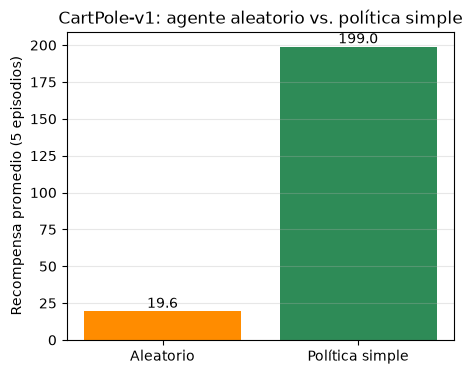

In [8]:
plt.figure(figsize=(5, 4))
bars = plt.bar(
    ["Aleatorio", "Política simple"],
    [np.mean(cartpole_random_returns), np.mean(cartpole_policy_returns)],
    color=["darkorange", "seagreen"],
)
plt.ylabel("Recompensa promedio (5 episodios)")
plt.title("CartPole-v1: agente aleatorio vs. política simple")
plt.bar_label(bars, fmt="%.1f")
plt.grid(True, axis="y", alpha=0.3)
plt.show()